In [39]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Configuración de rutas para los microdatos
ruta_csv = os.path.join('..', 'csv')

def cargar(nombre):
    path_completo = os.path.join(ruta_csv, nombre)
    return pd.read_csv(path_completo, sep=';', low_memory=False)

In [40]:
try:
    df_c = cargar('ArchivoC_Adm2025.csv')
    df_b = cargar('ArchivoB_Adm2025.csv')
    
    # Fusión por ID de alumno (ID_aux)
    df = pd.merge(df_c, df_b, on='ID_aux', how='inner')
    print(f"Bases fusionadas. Columnas totales disponibles: {len(df.columns)}")
except Exception as e:
    print(f"Error al cargar archivos: {e}")

Bases fusionadas. Columnas totales disponibles: 57


In [41]:
# Variables dependiente (Target) y predictoras académicas
target = 'MATE1_REG_ACTUAL'
n = 'PTJE_NEM'
r = 'PTJE_RANKING'

# Variables categóricas (Género, Dependencia, Región)
g = 'SEXO'
d = 'GRUPO_DEPENDENCIA_x'
c = 'CODIGO_REGION_x'

# Nuevas variables de vulnerabilidad e ingreso (para mejorar el R2)
ingreso = 'INGRESO_PERCAPITA_GRUPO_FA'
rama_ense = 'RAMA_EDUCACIONAL_x'
beca_bea = 'BEA'
prog_pace = 'PACE'

print("Variables configuradas correctamente.")

Variables configuradas correctamente.


In [42]:
# Lista de variables categóricas para transformar
vars_cat = [g, d, c, rama_ense, beca_bea, prog_pace, ingreso]

# Limpieza: Aseguramos puntajes y NEM positivos para el modelo
df_clean = df[(df[target] > 0) & (df[n] > 0)].copy()

# Conversión numérica forzada para evitar errores
for col in [target, n, r]:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Aplicamos One-Hot Encoding
X_raw = df_clean[[n, r] + vars_cat].copy()
X = pd.get_dummies(X_raw, columns=vars_cat, drop_first=True)
y = df_clean[target]

print(f"Registros listos: {len(df_clean)}")
print(f"Total de predictores tras encoding: {X.shape[1]}")

Registros listos: 241832
Total de predictores tras encoding: 39


In [43]:
from sklearn.model_selection import train_test_split

# 1. División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Modelo con restricciones de memoria para evitar el Crash
modelo_full = RandomForestRegressor(
    n_estimators=500,      # Reducimos la cantidad de árboles para ahorrar RAM
    max_depth=15,          # Limitamos la profundidad (esto evita el MemoryError)
    min_samples_leaf=10,   # Hojas más grandes para un modelo más ligero
    max_features='sqrt',   # Usa una fracción de variables por árbol (ahorra mucha memoria)
    n_jobs=2,              # No uses -1; usa 2 núcleos para no saturar la RAM
    random_state=42
)

# Ejecuta esta celda y asegúrate de que termine sin errores antes de pasar a la siguiente
modelo_full.fit(X_train, y_train)
print("Entrenamiento completado exitosamente.")

Entrenamiento completado exitosamente.


In [44]:
from sklearn.metrics import r2_score

# Ahora el objeto ya tiene los árboles cargados y podrá predecir
y_pred = modelo_full.predict(X_test)
r2_final = r2_score(y_test, y_pred)

print(f"--- RESULTADOS ---")
print(f"Coeficiente de determinación (R²): {r2_final:.4f}")

# Consolidación de importancia (Igual que antes)
importancias = modelo_full.feature_importances_
pesos_dict = {'NEM (N)': 0, 'Ranking (R)': 0, 'Género (G)': 0, 'Dependencia (D)': 0, 'Contexto (C)': 0, 'Socioeconómico': 0}

for i, col in enumerate(X.columns):
    if col == n: pesos_dict['NEM (N)'] += importancias[i]
    elif col == r: pesos_dict['Ranking (R)'] += importancias[i]
    elif g in col: pesos_dict['Género (G)'] += importancias[i]
    elif d in col: pesos_dict['Dependencia (D)'] += importancias[i]
    elif c in col: pesos_dict['Contexto (C)'] += importancias[i]
    else: pesos_dict['Socioeconómico'] += importancias[i]

pesos_df = pd.DataFrame(pesos_dict.items(), columns=['Factor', 'Peso_Porcentaje'])
pesos_df['Peso_Porcentaje'] *= 100
print(pesos_df.sort_values(by='Peso_Porcentaje', ascending=False).to_string(index=False))

--- RESULTADOS ---
Coeficiente de determinación (R²): 0.4624
         Factor  Peso_Porcentaje
        NEM (N)        34.210732
    Ranking (R)        27.026960
 Socioeconómico        16.162155
Dependencia (D)        12.154302
     Género (G)         7.758553
   Contexto (C)         2.687299


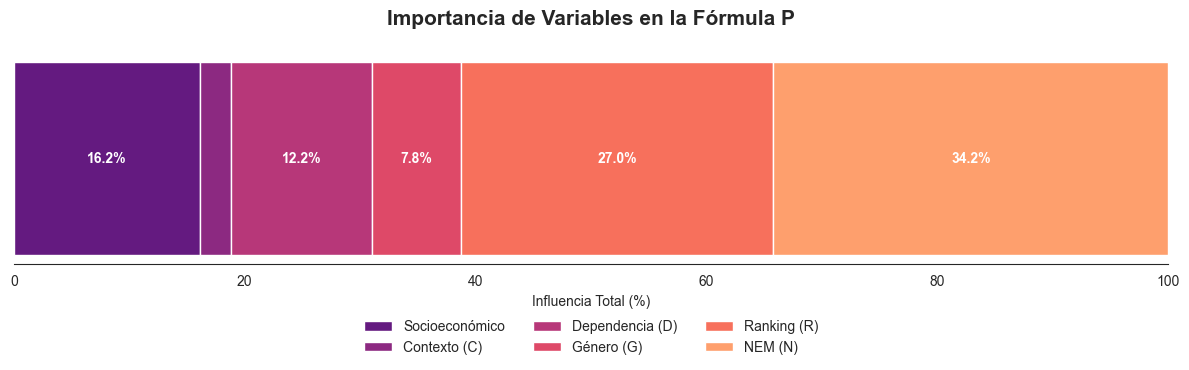

In [45]:
sns.set_style("white")
df_plot = pesos_df.iloc[::-1]

fig, ax = plt.subplots(figsize=(12, 4))
inicio = 0
colores = plt.cm.magma(np.linspace(0.3, 0.8, len(df_plot)))

for i, (idx, fila) in enumerate(df_plot.iterrows()):
    ancho = fila['Peso_Porcentaje']
    ax.barh(0, ancho, left=inicio, color=colores[i], label=fila['Factor'], edgecolor='white', height=0.6)
    if ancho > 4:
        ax.text(inicio + ancho/2, 0, f"{ancho:.1f}%", va='center', ha='center', color='white', fontweight='bold')
    inicio += ancho

ax.set_title('Importancia de Variables en la Fórmula P', fontsize=15, pad=20, fontweight='bold')
ax.set_xlabel('Influencia Total (%)')
ax.set_xlim(0, 100)
ax.set_yticks([])
sns.despine(left=True)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False)
plt.tight_layout()
plt.show()